In [1]:
import os, yaml, sys
import numpy as np
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
from general_utils.utils import BrainAreas, RSA, load_img_natraster, print_wise, TimeSeries
from general_utils.dRSA import across_areas_dRSA
from general_utils.II import InformationImbalance, compare_similarity_metrics

In [38]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    monkey_name: str = 'red' 
    date: str = '220227'
    brain_area: str = 'AIT'
    new_fs: int = 100 # Hz
    RDM_metric_A: str = 'cosine'
    RDM_metric_B: str = 'correlation'
    k: int = 1
cfg = Cfg()


In [51]:
raster_red = load_img_natraster(paths, cfg.monkey_name, cfg.date, new_fs=cfg.new_fs)
print(raster_red.get_array().shape)
ba_raster_red = TimeSeries(raster_red.get_array()[:30, :,:3000], cfg.new_fs)

(76, 50, 11855)


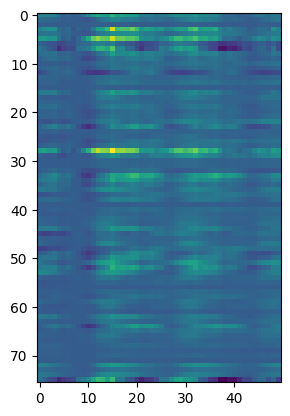

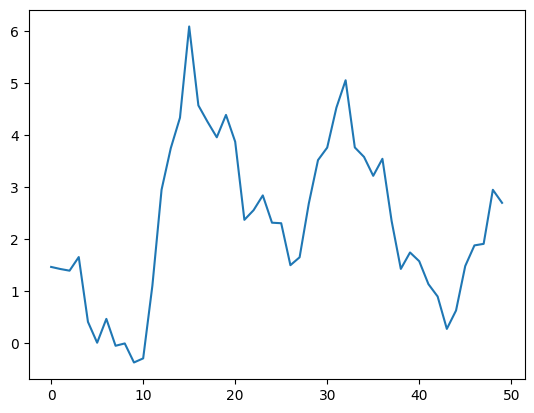

In [52]:
plt.imshow(np.mean(raster_red.get_array(), axis=(2)))
plt.figure()
plt.plot(np.mean(raster_red.get_array(), axis=(0,2)))

In [53]:
A2B_list = []
B2A_list = []
for idx, resp_t in enumerate(ba_raster_red):
    # col_norms = np.linalg.norm(resp_t, axis=0)
    # # normalize columns
    # resp_t = resp_t / col_norms
    _, A2B, B2A =compare_similarity_metrics(resp_t, cfg.RDM_metric_A, cfg.RDM_metric_B, cfg.k)
    A2B_list.append(A2B)
    B2A_list.append(B2A)
    print_wise(f"computed {idx*1000/cfg.new_fs:.0f}ms. {A2B:.3f} {B2A:.3f} ")

19:28:59 - computed 0ms. 0.001 0.009 
19:29:01 - computed 10ms. 0.001 0.008 
19:29:03 - computed 20ms. 0.001 0.007 
19:29:04 - computed 30ms. 0.001 0.007 
19:29:06 - computed 40ms. 0.001 0.008 
19:29:07 - computed 50ms. 0.001 0.007 
19:29:09 - computed 60ms. 0.001 0.008 
19:29:10 - computed 70ms. 0.001 0.008 
19:29:12 - computed 80ms. 0.001 0.007 
19:29:13 - computed 90ms. 0.001 0.007 
19:29:15 - computed 100ms. 0.001 0.006 
19:29:16 - computed 110ms. 0.001 0.007 
19:29:18 - computed 120ms. 0.001 0.005 
19:29:19 - computed 130ms. 0.001 0.006 
19:29:21 - computed 140ms. 0.001 0.006 
19:29:22 - computed 150ms. 0.001 0.005 
19:29:24 - computed 160ms. 0.001 0.006 
19:29:26 - computed 170ms. 0.001 0.005 
19:29:27 - computed 180ms. 0.001 0.007 
19:29:29 - computed 190ms. 0.001 0.005 
19:29:30 - computed 200ms. 0.001 0.006 
19:29:32 - computed 210ms. 0.001 0.006 
19:29:33 - computed 220ms. 0.001 0.007 
19:29:35 - computed 230ms. 0.001 0.007 
19:29:36 - computed 240ms. 0.001 0.007 
19:29:38 - 

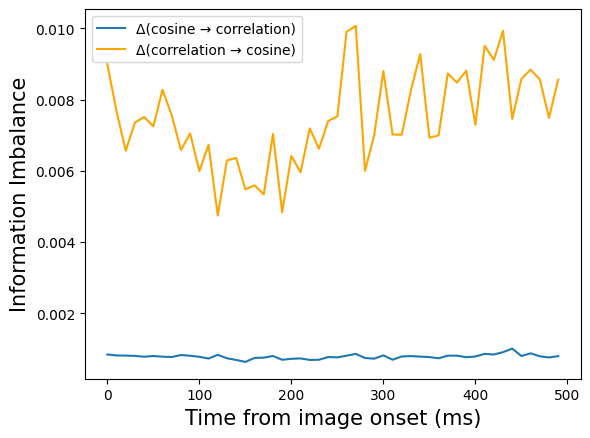

In [54]:
plt.plot(np.arange(0, len(A2B_list))*1000//cfg.new_fs,A2B_list, label=f"{chr(916)}({cfg.RDM_metric_A} {chr(8594)} {cfg.RDM_metric_B})")
plt.plot(np.arange(len(A2B_list))*1000//cfg.new_fs, B2A_list, label=f"{chr(916)}({cfg.RDM_metric_B} {chr(8594)} {cfg.RDM_metric_A})", color="orange")
plt.ylabel("Information Imbalance", fontsize=15)
plt.xlabel("Time from image onset (ms)", fontsize=15)
plt.legend()

In [ ]:
raster_baby5 = load_img_natraster(paths, 'baby5', '221104to24', new_fs=cfg.new_fs)
raster_baby5.get_array().shape

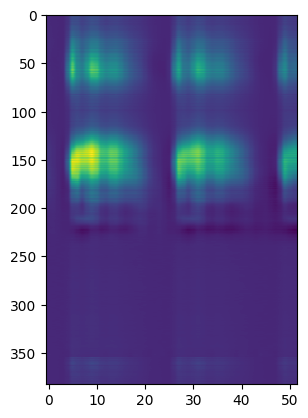

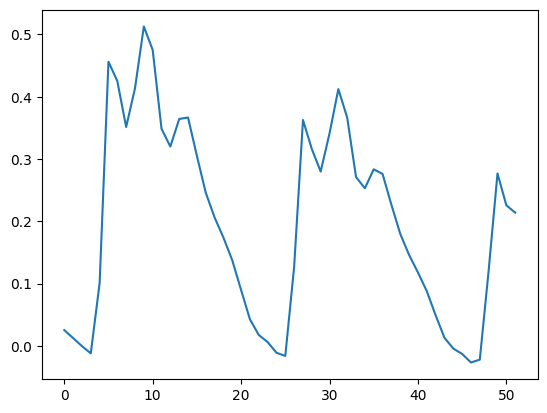

In [35]:
plt.imshow(np.mean(raster_baby5.get_array(), axis=2), aspect=1/5)
plt.figure()
plt.plot(np.mean(raster_baby5.get_array(), axis=(0,2)))

19:43:11 - computed 0ms. 0.003 0.020 
19:43:13 - computed 10ms. 0.003 0.013 
19:43:15 - computed 20ms. 0.002 0.013 
19:43:17 - computed 30ms. 0.002 0.015 
19:43:19 - computed 40ms. 0.002 0.132 
19:43:20 - computed 50ms. 0.002 0.026 
19:43:23 - computed 60ms. 0.001 0.041 
19:43:25 - computed 70ms. 0.002 0.073 
19:43:26 - computed 80ms. 0.001 0.091 
19:43:28 - computed 90ms. 0.001 0.047 
19:43:30 - computed 100ms. 0.002 0.047 
19:43:32 - computed 110ms. 0.002 0.065 
19:43:34 - computed 120ms. 0.002 0.104 
19:43:36 - computed 130ms. 0.002 0.106 
19:43:39 - computed 140ms. 0.001 0.090 
19:43:40 - computed 150ms. 0.002 0.079 
19:43:42 - computed 160ms. 0.002 0.076 
19:43:44 - computed 170ms. 0.002 0.108 
19:43:46 - computed 180ms. 0.002 0.186 
19:43:47 - computed 190ms. 0.003 0.222 
19:43:49 - computed 200ms. 0.003 0.252 
19:43:51 - computed 210ms. 0.003 0.260 
19:43:53 - computed 220ms. 0.005 0.247 
19:43:55 - computed 230ms. 0.004 0.256 
19:43:57 - computed 240ms. 0.004 0.233 
19:43:59 - 

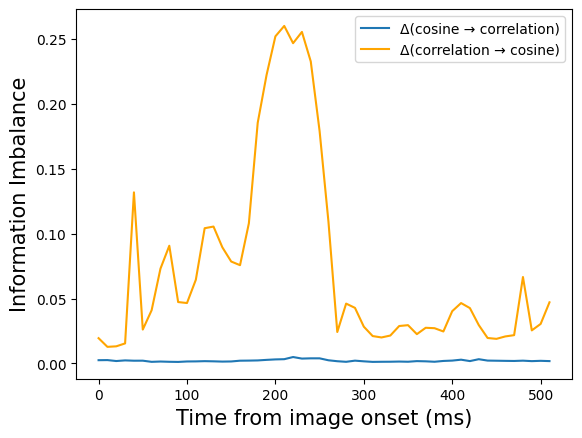

In [67]:
ba_raster_baby5 = TimeSeries(raster_baby5.get_array()[:20, :, :], cfg.new_fs)
A2B_list = []
B2A_list = []
for idx, resp_t in enumerate(ba_raster_baby5):
    # col_norms = np.linalg.norm(resp_t, axis=0)
    # # normalize columns
    # resp_t = resp_t / col_norms
    _, A2B, B2A =compare_similarity_metrics(resp_t, cfg.RDM_metric_A, cfg.RDM_metric_B, cfg.k)
    A2B_list.append(A2B)
    B2A_list.append(B2A)
    print_wise(f"computed {idx*1000/cfg.new_fs:.0f}ms. {A2B:.3f} {B2A:.3f} ")
    
plt.plot(np.arange(0, len(A2B_list))*1000//cfg.new_fs,A2B_list, label=f"{chr(916)}({cfg.RDM_metric_A} {chr(8594)} {cfg.RDM_metric_B})")
plt.plot(np.arange(len(A2B_list))*1000//cfg.new_fs, B2A_list, label=f"{chr(916)}({cfg.RDM_metric_B} {chr(8594)} {cfg.RDM_metric_A})", color="orange")
plt.ylabel("Information Imbalance", fontsize=15)
plt.xlabel("Time from image onset (ms)", fontsize=15)
plt.legend()

In [30]:
import h5py
from general_utils.utils import TimeSeries, BrainAreas
def load_img_natraster_three0(paths: dict[str: str], monkey_name, date, ev_od, new_fs=None, brain_area=None):
    rasters_path = f"{paths['livingstone_lab']}/tiziano/data/{monkey_name}_natraster{ev_od}{date}.mat"
    with h5py.File(rasters_path, "r") as f:
        rasters = f[f"natraster{ev_od}"][:]  
        
    rasters = rasters.astype(np.float32)
    rasters = rasters.transpose(2, 1, 0)
    rasters = TimeSeries(rasters, 1000)
    if brain_area is not None:
            brain_areas_obj = BrainAreas(monkey_name)
            rasters = brain_areas_obj.slice_brain_area(rasters, brain_area)
    # end if brain_area is not None:
    if new_fs is not None:
        rasters.resample(new_fs)
    # if new_fs is not None:
    return rasters
# EOF


In [58]:
# merge Even and odd trials (based also on the images) 
raster_three0 = load_img_natraster_three0(paths, 'three0', '250313', 'Od', new_fs=cfg.new_fs)
print(raster_three0.get_array().shape)
ba_raster_three0 = TimeSeries(raster_three0.get_array()[:30,:,:], cfg.new_fs)

(383, 30, 776)


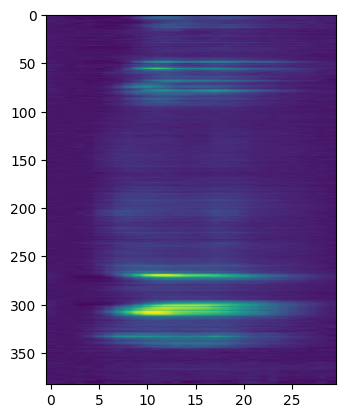

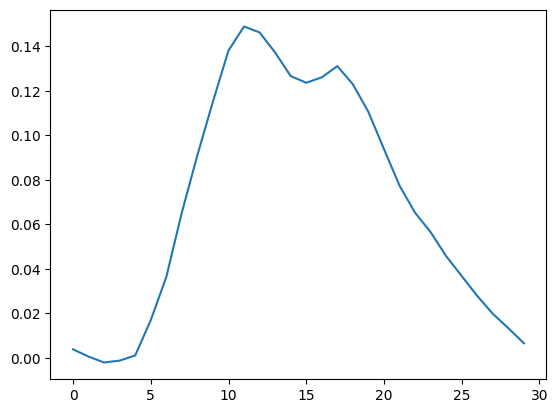

In [57]:
plt.imshow(np.mean(raster_three0.get_array(), axis=2),aspect=1/10) 
plt.figure()
plt.plot(np.mean(raster_three0.get_array(), axis=(0,2)))

19:44:44 - computed 0ms. 0.002 0.004 
19:44:44 - computed 10ms. 0.002 0.004 
19:44:44 - computed 20ms. 0.001 0.003 
19:44:44 - computed 30ms. 0.002 0.005 
19:44:44 - computed 40ms. 0.002 0.005 
19:44:44 - computed 50ms. 0.002 0.007 
19:44:44 - computed 60ms. 0.003 0.005 
19:44:45 - computed 70ms. 0.002 0.004 
19:44:45 - computed 80ms. 0.002 0.005 
19:44:45 - computed 90ms. 0.002 0.005 
19:44:45 - computed 100ms. 0.003 0.012 
19:44:45 - computed 110ms. 0.003 0.020 
19:44:45 - computed 120ms. 0.003 0.020 
19:44:45 - computed 130ms. 0.004 0.017 
19:44:45 - computed 140ms. 0.004 0.015 
19:44:46 - computed 150ms. 0.003 0.017 
19:44:46 - computed 160ms. 0.004 0.028 
19:44:46 - computed 170ms. 0.004 0.021 
19:44:46 - computed 180ms. 0.003 0.021 
19:44:46 - computed 190ms. 0.003 0.018 
19:44:46 - computed 200ms. 0.003 0.015 
19:44:46 - computed 210ms. 0.003 0.014 
19:44:46 - computed 220ms. 0.004 0.014 
19:44:46 - computed 230ms. 0.002 0.006 
19:44:46 - computed 240ms. 0.002 0.010 
19:44:47 - 

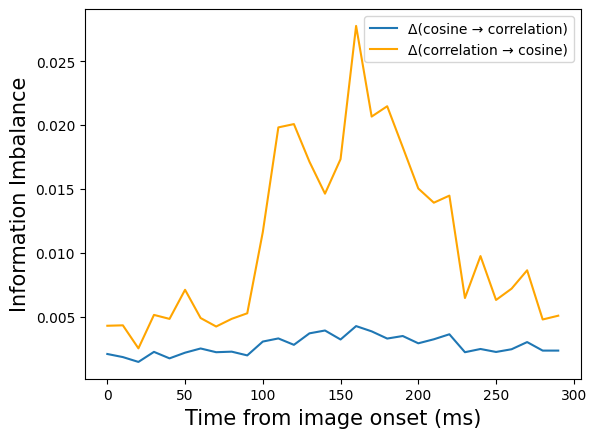

In [68]:
A2B_list=[]
B2A_list=[]
for idx, resp_t in enumerate(ba_raster_three0):
    # col_norms = np.linalg.norm(resp_t, axis=0)
    # # normalize columns
    # resp_t = resp_t / col_norms
    _, A2B, B2A =compare_similarity_metrics(resp_t, cfg.RDM_metric_A, cfg.RDM_metric_B, cfg.k)
    A2B_list.append(A2B)
    B2A_list.append(B2A)
    print_wise(f"computed {idx*1000/cfg.new_fs:.0f}ms. {A2B:.3f} {B2A:.3f} ")
    
plt.plot(np.arange(0, len(A2B_list))*1000//cfg.new_fs,A2B_list, label=f"{chr(916)}({cfg.RDM_metric_A} {chr(8594)} {cfg.RDM_metric_B})")
plt.plot(np.arange(len(A2B_list))*1000//cfg.new_fs, B2A_list, label=f"{chr(916)}({cfg.RDM_metric_B} {chr(8594)} {cfg.RDM_metric_A})", color="orange")
plt.ylabel("Information Imbalance", fontsize=15)
plt.xlabel("Time from image onset (ms)", fontsize=15)
plt.legend()